In [23]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay



# Importar datos

Datos tomados de https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset?select=diabetes_binary_5050split_health_indicators_BRFSS2015.csv

In [11]:
diabetes_df = pd.read_csv('.\\diabetes_dataset.csv')
diabetes_df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


# Preparar los datos y Construir el algoritmo

### Separar los datos

In [32]:
X = diabetes_df.drop('Diabetes_binary', axis=1)
y = diabetes_df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Instanciar el modelo y usar .fit() con los datos de entrenamiento

In [34]:
from sklearn.ensemble import RandomForestClassifier
clasificador = RandomForestClassifier()
clasificador.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Realizar predicciones sobre el conjunto de prueba

In [21]:
y_pred = clasificador.predict(X_test)

### Evaluacion del algoritmo

#### Matriz de confusion
La matriz de confusión es una herramienta de evaluación para modelos de aprendizaje automático supervisado (clasificación) que resume el rendimiento de un modelo comparando los valores predichos con los reales

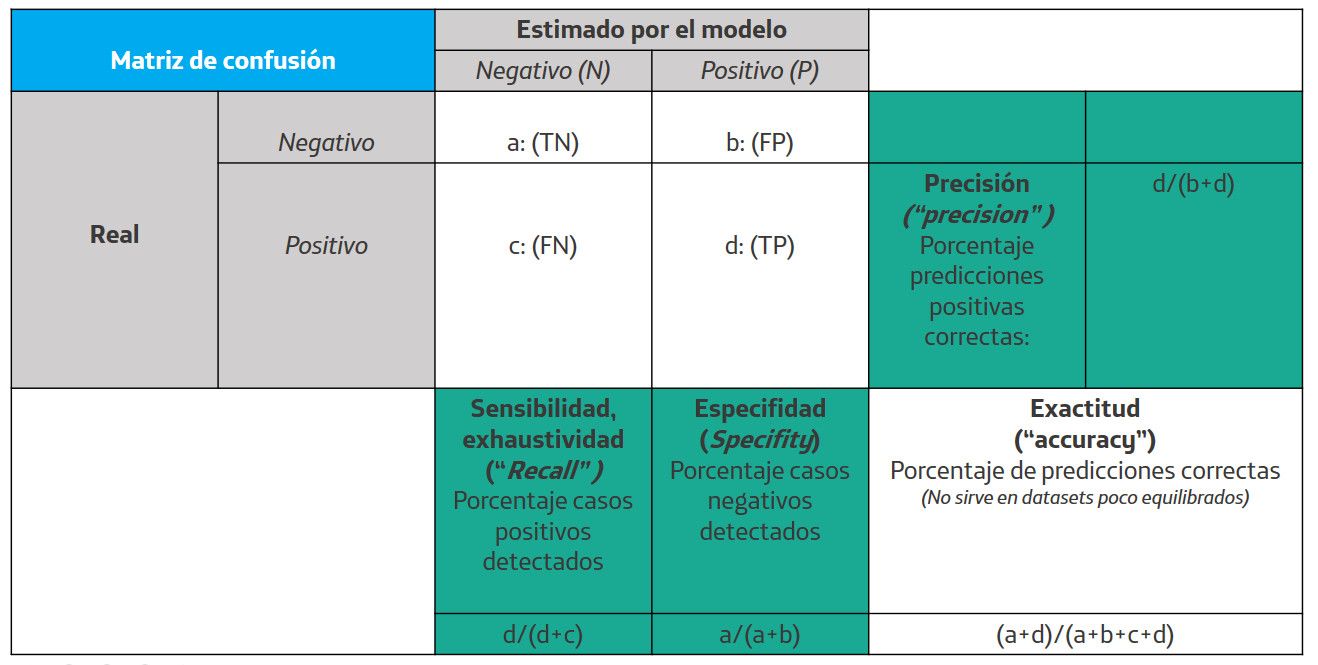

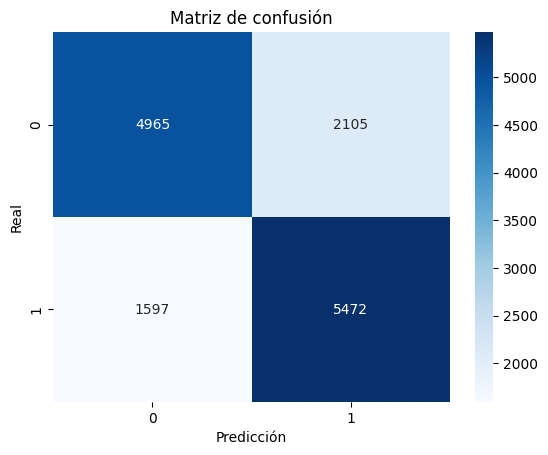

In [26]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [35]:
X_test.shape

(14139, 21)

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.76      0.70      0.73      7070
         1.0       0.72      0.77      0.75      7069

    accuracy                           0.74     14139
   macro avg       0.74      0.74      0.74     14139
weighted avg       0.74      0.74      0.74     14139



Otra manera de entender las métricas:

- Accuracy: ¿Cuántas veces acertó en total el modelo? --> Sirve cuando el dataset está balanceado
- Precision: De todo lo que el modelo predijo como positivo, ¿Que porcentaje de estos eran correcto? --> Me sirve para evitar falsos positivos
- Recall: De todos los positivos reales, ¿¿Que porcentaje de estos encontró el modelo? --> Me sirve para evitar falsos negativos
- F1-Score: Balance entre Precision y Recall --> Sirve cuando el dataset NO está balanceado

# Ajuste de hiperparámetros

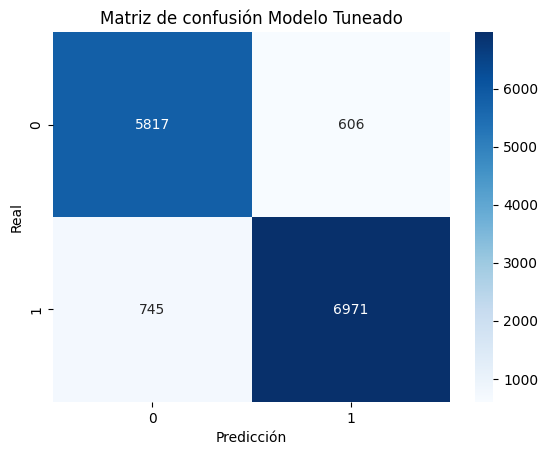

              precision    recall  f1-score   support

         0.0       0.77      0.70      0.74      7070
         1.0       0.73      0.80      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



In [42]:
clasificador_tuneado = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

clasificador_tuneado.fit(X_train, y_train)
y_pred_tuneado = clasificador_tuneado.predict(X_test)
cm = confusion_matrix(y_pred_tuneado, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusión Modelo Tuneado')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()
print(classification_report(y_test, y_pred_tuneado))

In [60]:
## GridSearch CV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

cv = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, scoring='recall')

cv.fit(X_train, y_train)
print(f'Mejor modelo: {cv.best_estimator_}')
y_pred_cv = cv.predict(X_test)

Mejor modelo: RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                       random_state=42)


              precision    recall  f1-score   support

         0.0       0.77      0.71      0.74      7070
         1.0       0.73      0.79      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



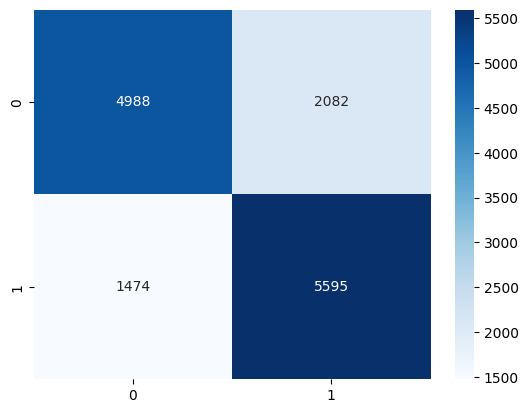

In [ ]:
cm = confusion_matrix(y_test, y_pred_cv)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
print(classification_report(y_test, y_pred_cv))
plt.title(f'Matriz de confusión Mejor Version Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')


# Ajuste de hiperparametros para KNN  (K Nearest Neighbors)

In [68]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()


param_grid = {
    'n_neighbors': [3,5,8,12],
    'weights': ['uniform', 'distance'],
    'algorithm': ['ball_tree', 'kd_tree', 'brute']
}

## Estimtor = Instancia del modelo que queremos tunear
## param_grid = Diccionario con los hiperparámetros que queremos probar
## cv = Número de pliegues para la validación cruzada (Pliegues = Subconjuntos del conjunto original de los datos)
## n_jobs = Número de núcleos a utilizar para el procesamiento paralelo (-1 utiliza todos los núcleos disponibles)
## scoring = Métrica que se utilizará para evaluar el rendimiento de los modelos durante la búsqueda (en este caso, 'recall' para maximizar la capacidad de detectar casos positivos)

cv = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, scoring='recall')


cv.fit(X_train, y_train)
print(f'Mejor modelo: {cv.best_estimator_}')
y_pred_cv = cv.predict(X_test)


Mejor modelo: KNeighborsClassifier(algorithm='kd_tree', n_neighbors=12, weights='distance')


              precision    recall  f1-score   support

         0.0       0.73      0.68      0.71      7070
         1.0       0.70      0.75      0.73      7069

    accuracy                           0.72     14139
   macro avg       0.72      0.72      0.72     14139
weighted avg       0.72      0.72      0.72     14139



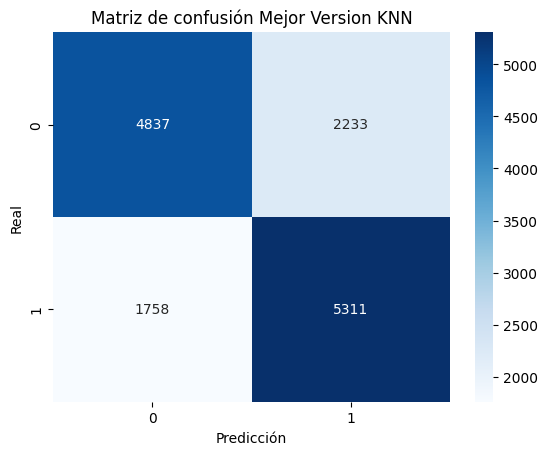

In [71]:
cm = confusion_matrix(y_test, y_pred_cv)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
print(classification_report(y_test, y_pred_cv))
plt.title(f'Matriz de confusión Mejor Version KNN')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Ajuste de hiperparametros para XGBOOSTING

In [72]:
from xgboost import XGBClassifier


xgb_clasificador = XGBClassifier()

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
}

## Estimtor = Instancia del modelo que queremos tunear
## param_grid = Diccionario con los hiperparámetros que queremos probar
## cv = Número de pliegues para la validación cruzada (Pliegues = Subconjuntos del conjunto original de los datos)
## n_jobs = Número de núcleos a utilizar para el procesamiento paralelo (-1 utiliza todos los núcleos disponibles)
## scoring = Métrica que se utilizará para evaluar el rendimiento de los modelos durante la búsqueda (en este caso, 'recall' para maximizar la capacidad de detectar casos positivos)

cv = GridSearchCV(estimator=XGBClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, scoring='recall')


cv.fit(X_train, y_train)
print(f'Mejor modelo: {cv.best_estimator_}')
y_pred_cv = cv.predict(X_test)


Mejor modelo: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)


              precision    recall  f1-score   support

         0.0       0.78      0.71      0.74      7070
         1.0       0.73      0.80      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



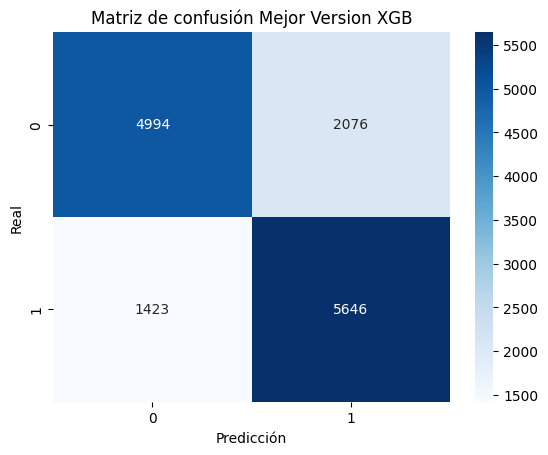

In [74]:
cm = confusion_matrix(y_test, y_pred_cv)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
print(classification_report(y_test, y_pred_cv))
plt.title(f'Matriz de confusión Mejor Version XGB')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()